In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot

c:\Users\sbout\Documents\school\URI\capstone\covid-housing-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = '../data/processed/processed_data_pre_model.csv'
# read the necessary columns from the datafile and make date column into Datetime object
df = pd.read_csv(file_path, usecols=['date', 'median_listing_price_x', 'state'])
df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y-%m-%d')

# Prophet takes two columns, ds and y, date and target.  Make function to prep df
def prep_data(ds):
  date_col='date'
  target_col='median_listing_price_x'
  pdf = ds[[date_col, target_col]].copy()
  pdf.columns = ['ds', 'y']
  pdf = pdf.dropna()
  pdf.sort_values(by='ds', inplace=True)
  return pdf

In [3]:
# Create a 'Region' column to split the dataset
df['Region'] = 'Rest of US'

# Change Region value to Florida for state_id = fl
df.loc[df['state'] == 'fl', 'Region'] = 'Florida'

# Split dataset into FL and rest of US
df_rous, df_fl = [x for _, x in df.groupby(df['Region'] == 'Florida')]


In [4]:
# prepare datasets for Prophet:  all, FL, rest of US
pdf_all = prep_data(df)
pdf_fl = prep_data(df_fl)
pdf_rous = prep_data(df_rous)

In [5]:
# Initialize Prophet Model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(pdf_fl)

17:01:23 - cmdstanpy - INFO - Chain [1] start processing
17:01:24 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

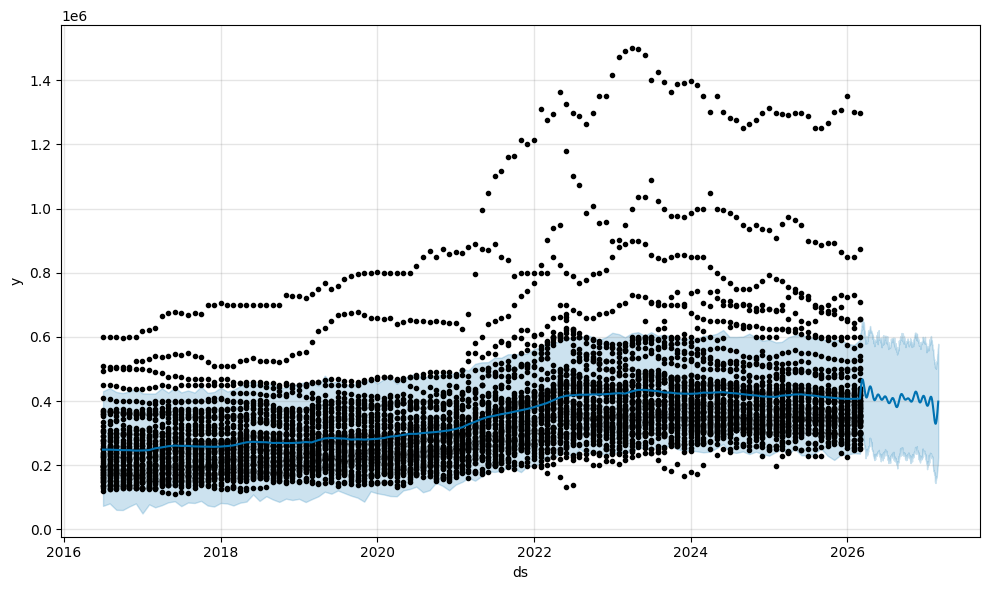

In [7]:
fig1 = model.plot(forecast)

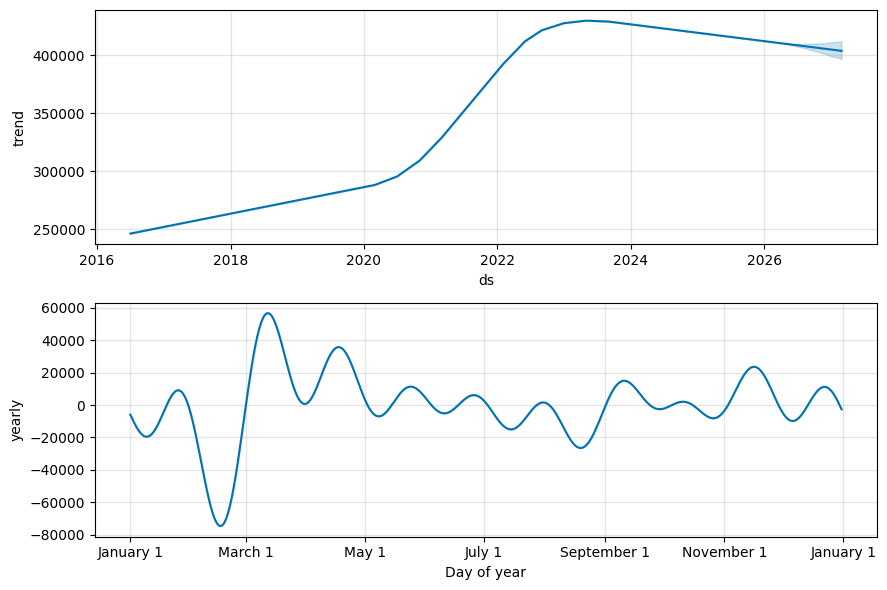

In [8]:
fig2 = model.plot_components(forecast)

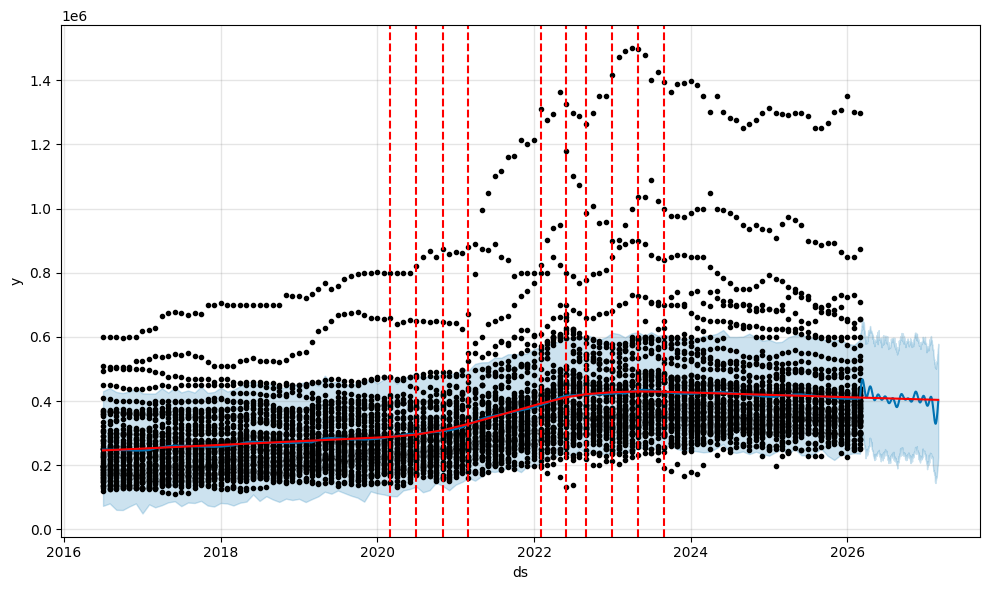

In [9]:
fig3 = model.plot(forecast)
a = add_changepoints_to_plot(fig3.gca(), model, forecast)


In [10]:
# use Prophet's cross-validation to check performance
df_cv = cross_validation(model, initial='3165 days', period='30 days', horizon = '365 days')
df_cv.head()

  0%|          | 0/1 [00:00<?, ?it/s]17:01:25 - cmdstanpy - INFO - Chain [1] start processing
17:01:26 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2025-04-01,424385.88035,230905.775229,578170.612523,430000.0,2025-03-01
1,2025-04-01,424385.88035,242363.207462,601156.317097,333225.0,2025-03-01
2,2025-04-01,424385.88035,235080.362046,603551.502463,431500.0,2025-03-01
3,2025-04-01,424385.88035,246576.418661,600913.769881,625000.0,2025-03-01
4,2025-04-01,424385.88035,244667.308434,602225.489884,1290000.0,2025-03-01


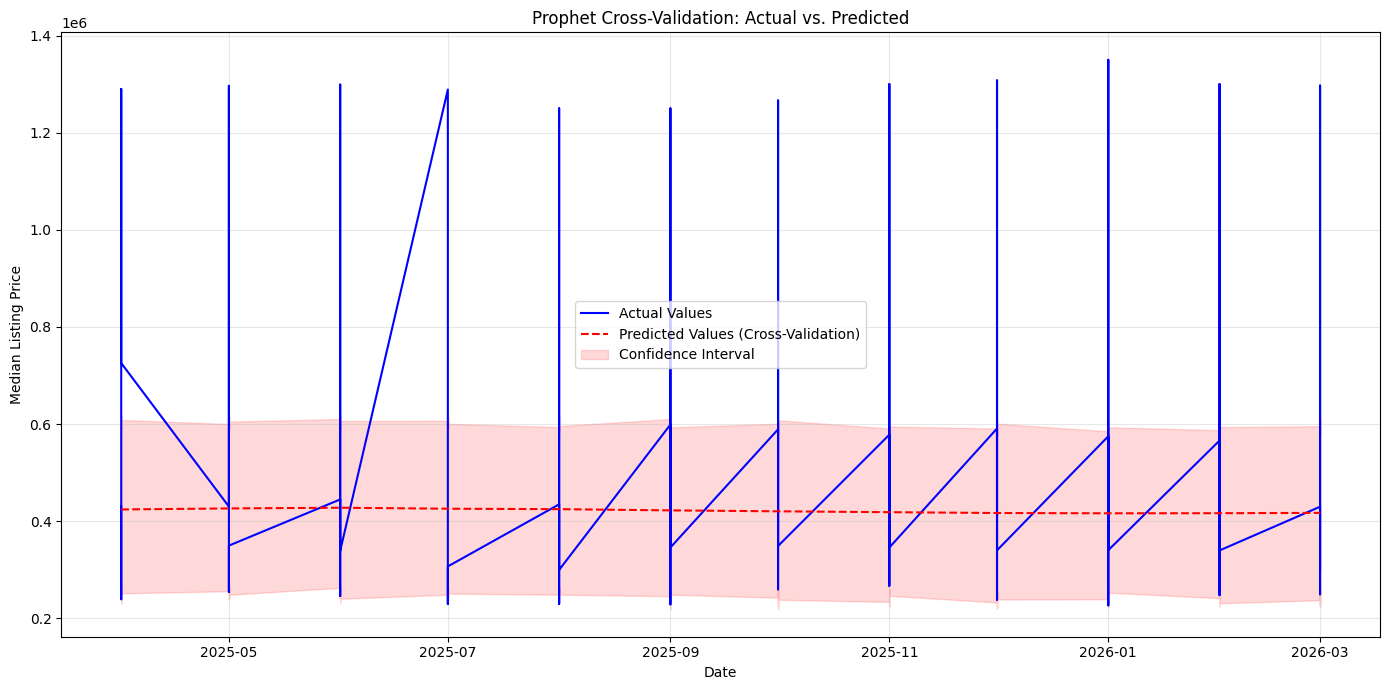

In [11]:
plt.figure(figsize=(14, 7))
plt.plot(df_cv['ds'], df_cv['y'], label='Actual Values', color='blue')
plt.plot(df_cv['ds'], df_cv['yhat'], label='Predicted Values (Cross-Validation)', color='red', linestyle='--')
plt.fill_between(df_cv['ds'], df_cv['yhat_lower'], df_cv['yhat_upper'], color='red', alpha=0.15, label='Confidence Interval')
plt.title('Prophet Cross-Validation: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Median Listing Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
df_p = performance_metrics(df_cv)
display(df_p.head())

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,61 days,2.674644e+10,163543.375218,102095.077678,0.230366,0.214297,0.222137,0.885821
1,92 days,2.627361e+10,162091.374172,102402.031204,0.233216,0.223883,0.223802,0.883022
2,122 days,2.528483e+10,159012.049492,100888.881414,0.234575,0.218767,0.223152,0.868097
3,153 days,2.396236e+10,154797.794839,99504.297633,0.236455,0.214532,0.223126,0.878172
4,184 days,2.376935e+10,154173.118168,99135.517172,0.236499,0.209394,0.223397,0.905597


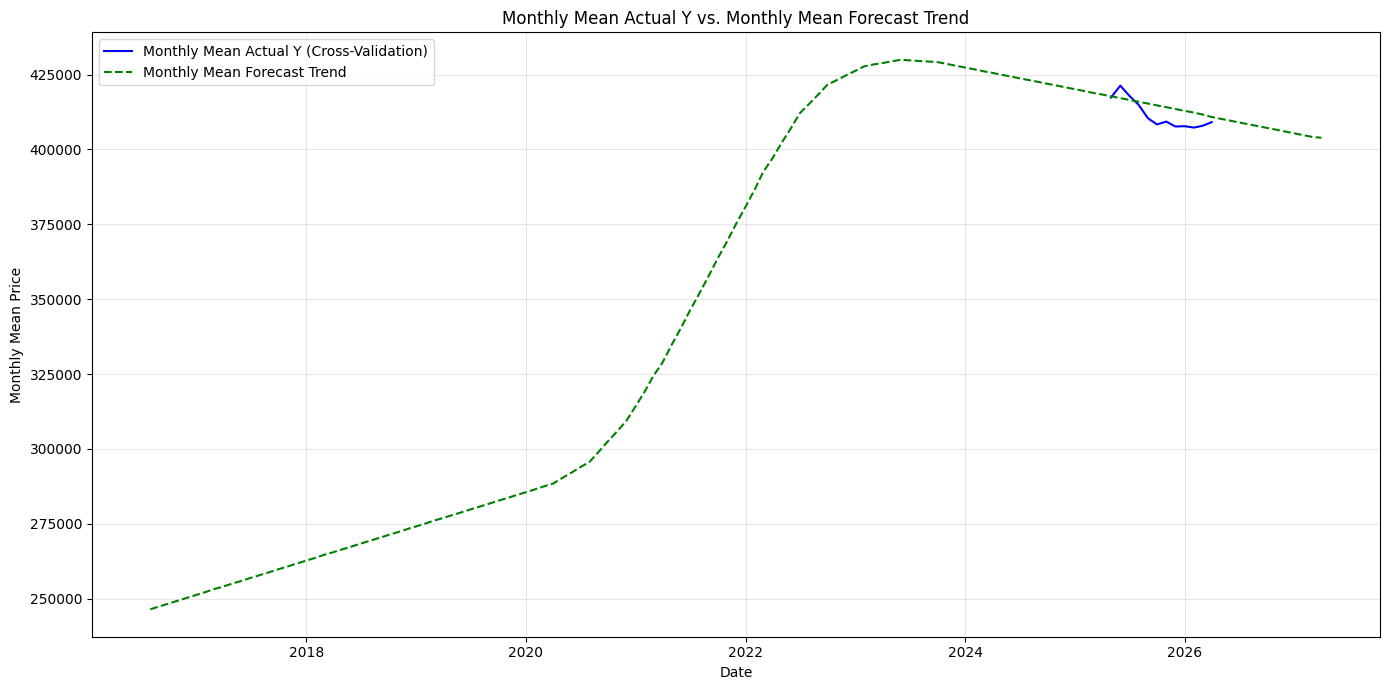

In [13]:
import matplotlib.pyplot as plt

# Aggregate df_cv to monthly mean of 'y'
df_cv_monthly = df_cv.set_index('ds').resample('ME')['y'].mean().reset_index()
df_cv_monthly.rename(columns={'y': 'monthly_mean_y'}, inplace=True)

# Aggregate forecast to monthly mean of 'trend'
forecast_monthly = forecast.set_index('ds').resample('ME')['trend'].mean().reset_index()
forecast_monthly.rename(columns={'trend': 'monthly_mean_trend'}, inplace=True)

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(df_cv_monthly['ds'], df_cv_monthly['monthly_mean_y'], label='Monthly Mean Actual Y (Cross-Validation)', color='blue')
plt.plot(forecast_monthly['ds'], forecast_monthly['monthly_mean_trend'], label='Monthly Mean Forecast Trend', color='green', linestyle='--')
plt.title('Monthly Mean Actual Y vs. Monthly Mean Forecast Trend')
plt.xlabel('Date')
plt.ylabel('Monthly Mean Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()